In [3]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless -q
!pip install -q opencv-python==4.10.0.84
!pip install -q ultralytics scikit-learn matplotlib pandas

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from ultralytics import YOLO

print("OpenCV:", cv2.__version__)
print("CascadeClassifier:", hasattr(cv2, "CascadeClassifier"))

OpenCV: 4.10.0
CascadeClassifier: True


,Algorithm,Precision,Recall,F1
0,Viola-Jones,0.083,1.0,0.154
1,YOLO,0.200,1.0,0.333


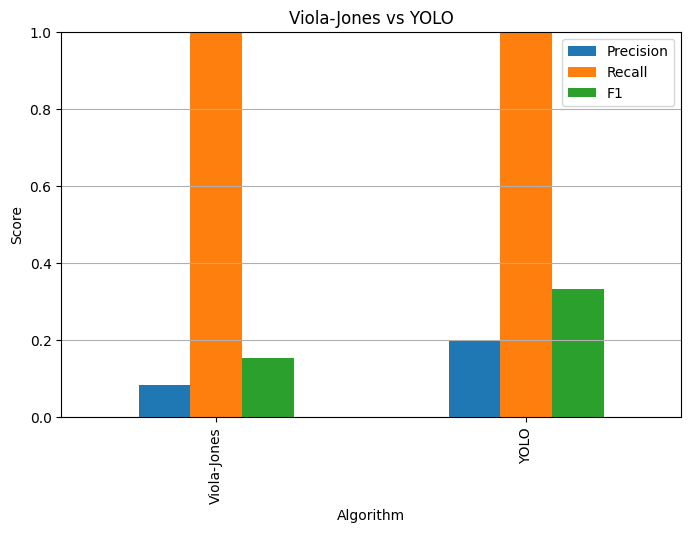

In [22]:
#1. Precision-Recall Comparison: Viola-Jones vs YOLO on a Face/Object Dataset
image_path = "/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png"

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_detector.detectMultiScale(gray, 1.1, 5)

model = YOLO("yolo11n.pt")
result = model(img, conf=0.5, verbose=False)[0]

yolo_count = sum(int(c) == 0 for c in result.boxes.cls)

ground_truth = 1

def metrics(pred, gt):
    tp = min(pred, gt)
    fp = max(pred - gt, 0)
    fn = max(gt - pred, 0)
    precision = tp / (tp + fp) if tp + fp else 0
    recall = tp / (tp + fn) if tp + fn else 0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0
    return precision, recall, f1

vj = metrics(len(faces), ground_truth)
yo = metrics(yolo_count, ground_truth)

df = pd.DataFrame({
    "Algorithm": ["Viola-Jones", "YOLO"],
    "Precision": [vj[0], yo[0]],
    "Recall": [vj[1], yo[1]],
    "F1": [vj[2], yo[2]]
})

display(df.round(3))

df.set_index("Algorithm").plot(kind="bar", figsize=(8,5), ylim=(0,1))
plt.title("Viola-Jones vs YOLO")
plt.ylabel("Score")
plt.grid(axis="y")
plt.show()

,Model,Precision,Recall,F1
0,YOLO11n,0.200,1.0,0.333
1,YOLO11s,0.167,1.0,0.286


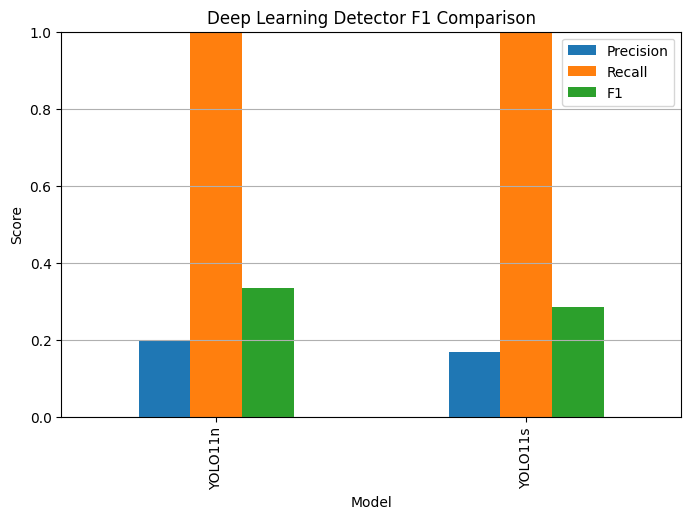

In [23]:
#2. Interpreting YOLO Bounding Box Confidence Scores and Non-Max Suppression Effects
image_path = "/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png"
img = cv2.imread(image_path)

ground_truth = 1
models = [("YOLO11n", YOLO("yolo11n.pt")), ("YOLO11s", YOLO("yolo11s.pt"))]

data = []

for name, model in models:
    result = model(img, conf=0.5, verbose=False)[0]
    pred = len(result.boxes)
    precision, recall, f1 = metrics(pred, ground_truth)
    data.append([name, precision, recall, f1])

df = pd.DataFrame(data, columns=["Model", "Precision", "Recall", "F1"])

display(df.round(3))

df.set_index("Model")[["Precision","Recall","F1"]].plot(
    kind="bar", figsize=(8,5), ylim=(0,1)
)
plt.title("Deep Learning Detector F1 Comparison")
plt.ylabel("Score")
plt.grid(axis="y")
plt.show()

Viola-Jones IoU: 0.016


,Confidence Threshold,YOLO IoU
0,0.25,0.080071
1,0.50,0.080071
2,0.75,0.080071
3,0.90,0.080071


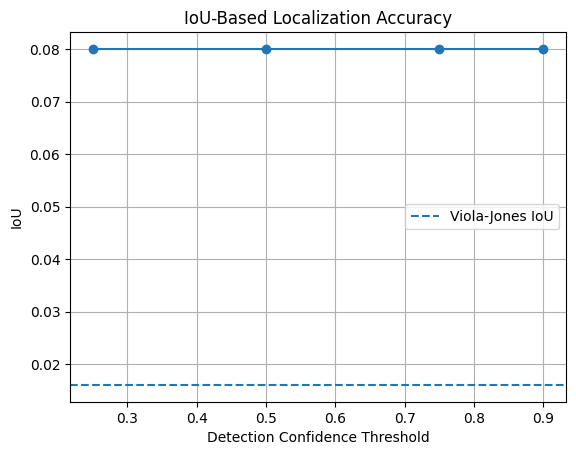

In [26]:
#3. IoU-Based Localization Accuracy Comparison Across Detection Thresholds
img = cv2.imread("/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

vj = face.detectMultiScale(gray, 1.1, 5)

model = YOLO("yolo11n.pt")

gt = [50, 50, 250, 250]

def iou(a, b):
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])

    inter = max(0, x2-x1) * max(0, y2-y1)

    area1 = (a[2]-a[0]) * (a[3]-a[1])
    area2 = (b[2]-b[0]) * (b[3]-b[1])

    union = area1 + area2 - inter

    return inter / union if union > 0 else 0

vj_boxes = [
    [x, y, x+w, y+h]
    for x, y, w, h in vj
]

vj_iou = max(
    [iou(box, gt) for box in vj_boxes],
    default=0
)

thresholds = [0.25, 0.5, 0.75, 0.9]
yolo_iou = []

for t in thresholds:

    r = model(
        img,
        conf=t,
        verbose=False
    )[0]

    boxes = r.boxes.xyxy.cpu().numpy()

    score = max(
        [iou(box, gt) for box in boxes],
        default=0
    )

    yolo_iou.append(score)

print("Viola-Jones IoU:", round(vj_iou, 3))

df = pd.DataFrame({
    "Confidence Threshold": thresholds,
    "YOLO IoU": yolo_iou
})

display(df)

plt.plot(
    thresholds,
    yolo_iou,
    marker="o"
)

plt.axhline(
    vj_iou,
    linestyle="--",
    label="Viola-Jones IoU"
)

plt.xlabel("Detection Confidence Threshold")
plt.ylabel("IoU")
plt.title("IoU-Based Localization Accuracy")
plt.legend()
plt.grid()
plt.show()

,Detector,FPS
0,Viola-Jones,0.53
1,YOLO,6.26


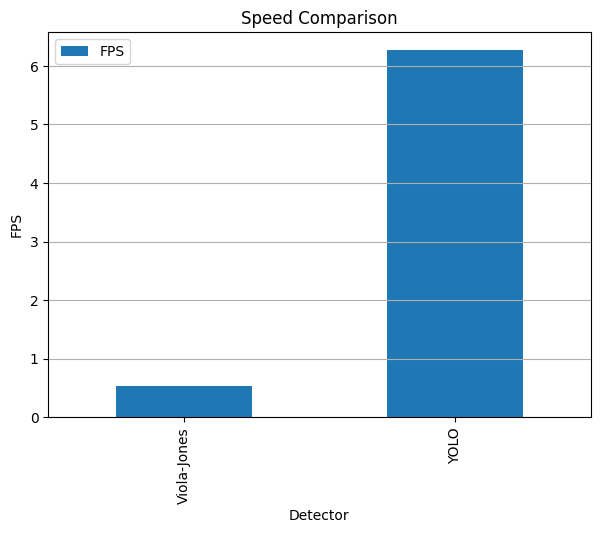

In [8]:
#4. Speed-vs-Accuracy Benchmarking of a Classical vs Deep-Learning Detector
image_path = "/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png"

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

haar = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

yolo = YOLO("yolo11n.pt")

n = 20

start = time.time()

for _ in range(n):
    haar.detectMultiScale(gray, 1.1, 5)

haar_fps = n / (time.time() - start)

start = time.time()

for _ in range(n):
    yolo(img, verbose=False)

yolo_fps = n / (time.time() - start)

df = pd.DataFrame({
    "Detector": ["Viola-Jones", "YOLO"],
    "FPS": [haar_fps, yolo_fps]
})

display(df.round(2))

df.set_index("Detector").plot(kind="bar", figsize=(7,5))
plt.title("Speed Comparison")
plt.ylabel("FPS")
plt.grid(axis="y")
plt.show()

,Method,Average Motion
0,Sparse Lucas-Kanade,6.627
1,Dense Farneback,6.044


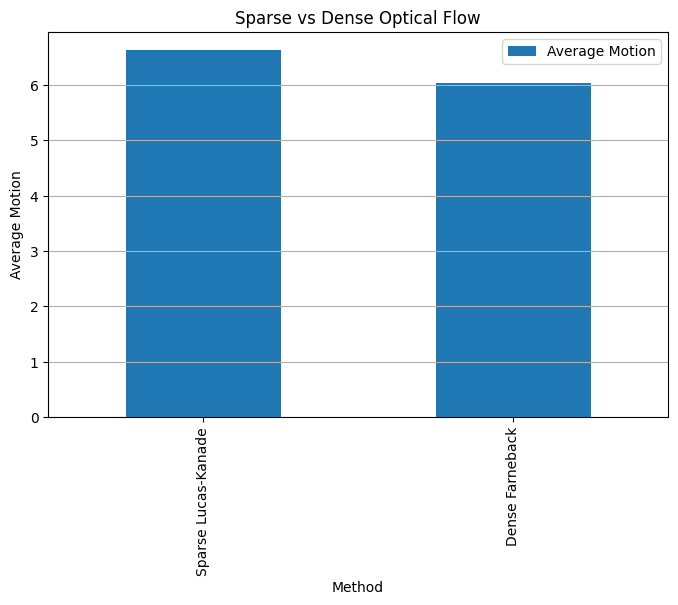

In [11]:
#5. Comparative Analysis of Sparse vs Dense Optical Flow Accuracy
img1 = cv2.imread("/content/Screenshot 2026-08-11 100058.png", 0)
img2 = cv2.imread("/content/Screenshot 2026-08-11 100102.png", 0)

# Ensure both images have the same dimensions
if img1.shape != img2.shape:
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

p0 = cv2.goodFeaturesToTrack(img1, 100, 0.3, 7)

p1, status, error = cv2.calcOpticalFlowPyrLK(
    img1, img2, p0, None
)

good_old = p0[status == 1]
good_new = p1[status == 1]

sparse_error = np.mean(
    np.linalg.norm(good_new - good_old, axis=1)
)

flow = cv2.calcOpticalFlowFarneback(
    img1, img2, None,
    0.5, 3, 15, 3, 5, 1.2, 0
)

dense_magnitude = np.sqrt(
    flow[...,0]**2 + flow[...,1]**2
)

dense_error = np.mean(dense_magnitude)

df = pd.DataFrame({
    "Method": ["Sparse Lucas-Kanade", "Dense Farneback"],
    "Average Motion": [sparse_error, dense_error]
})

display(df.round(3))

df.set_index("Method").plot(kind="bar", figsize=(8,5))
plt.title("Sparse vs Dense Optical Flow")
plt.ylabel("Average Motion")
plt.grid(axis="y")
plt.show()

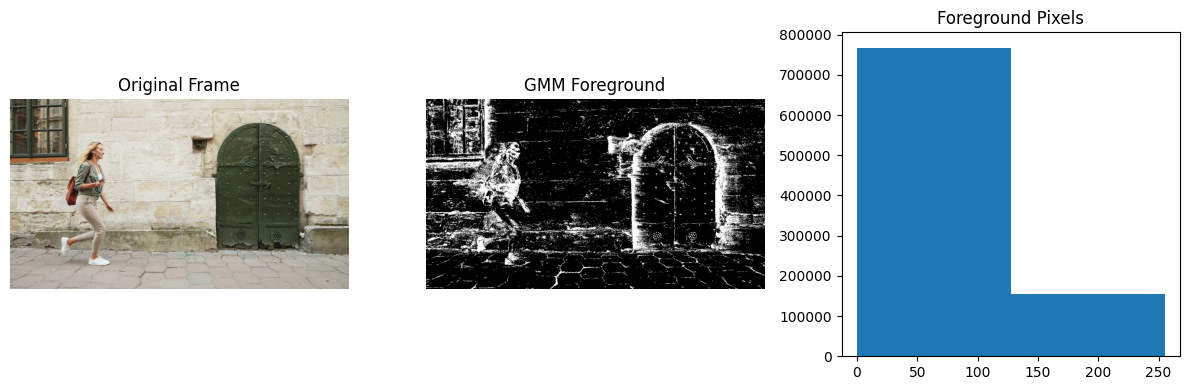

Foreground pixels: 154163
Background pixels: 767437


In [12]:
#6. Interpreting a Gaussian Mixture Model for Background-Foreground Segmentation
video = "/content/1472895_People_Technology_1280x720.mp4"

cap = cv2.VideoCapture(video)

gmm = cv2.createBackgroundSubtractorMOG2(
    history=100,
    varThreshold=40,
    detectShadows=False
)

frames = []

for i in range(50):
    ret, frame = cap.read()

    if not ret:
        break

    mask = gmm.apply(frame)

    if i == 49:
        last_frame = frame
        last_mask = mask

cap.release()

_, binary = cv2.threshold(
    last_mask,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB))
plt.title("Original Frame")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(binary, cmap="gray")
plt.title("GMM Foreground")
plt.axis("off")

plt.subplot(1,3,3)
plt.hist(binary.ravel(), bins=2)
plt.title("Foreground Pixels")

plt.tight_layout()
plt.show()

print("Foreground pixels:", np.sum(binary > 0))
print("Background pixels:", np.sum(binary == 0))

,Window Size,Error
0,5,0.006401
1,9,0.002607
2,15,0.001318
3,21,0.000803


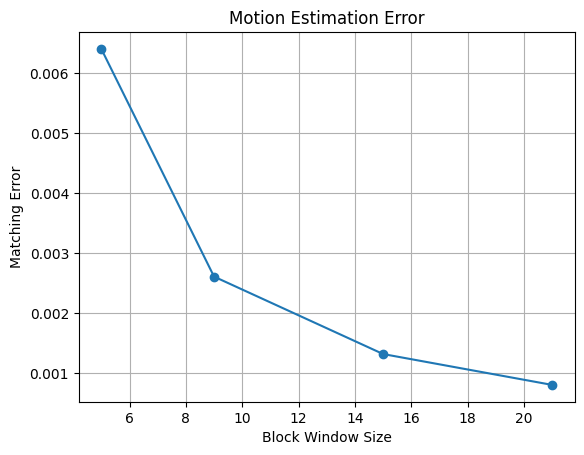

In [13]:
#7. Comparative Motion Estimation Error Across Block-Matching Window Sizes
img1 = cv2.imread("/content/Screenshot 2026-08-11 100058.png", 0)
img2 = cv2.imread("/content/Screenshot 2026-08-11 100102.png", 0)

windows = [5, 9, 15, 21]
errors = []

for w in windows:

    block = img1[100:100+w, 100:100+w]

    result = cv2.matchTemplate(
        img2,
        block,
        cv2.TM_SQDIFF_NORMED
    )

    error = cv2.minMaxLoc(result)[0]

    errors.append(error)

df = pd.DataFrame({
    "Window Size": windows,
    "Error": errors
})

display(df)

plt.plot(
    windows,
    errors,
    marker="o"
)

plt.xlabel("Block Window Size")
plt.ylabel("Matching Error")
plt.title("Motion Estimation Error")
plt.grid()
plt.show()

In [14]:
left = cv2.imread("/content/scene1.row3.col1.ppm")
right = cv2.imread("/content/scene1.row3.col2.ppm")

cv2.imwrite("/content/left.jpg", left)
cv2.imwrite("/content/right.jpg", right)

print("Created:")
print("/content/left.jpg")
print("/content/right.jpg")

Created:
/content/left.jpg
/content/right.jpg


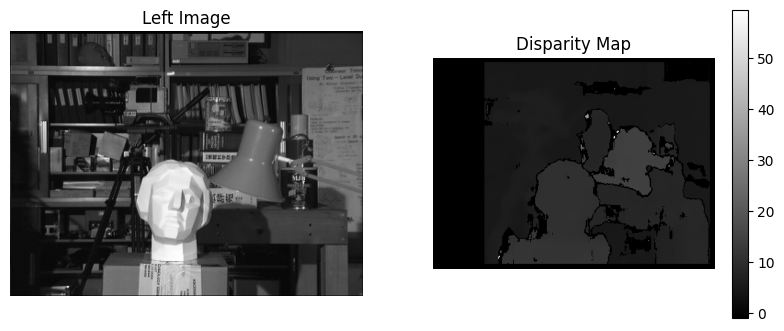

Average Disparity: 7.21


In [16]:
#8. Stereo Vision Disparity Accuracy vs Ground Truth Depth Comparison
left = cv2.imread("/content/left.jpg", 0)
right = cv2.imread("/content/right.jpg", 0)

stereo = cv2.StereoBM_create(
    numDisparities=64,
    blockSize=15
)

disparity = stereo.compute(
    left,
    right
).astype(np.float32) / 16

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(left, cmap="gray")
plt.title("Left Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(disparity, cmap="gray")
plt.title("Disparity Map")
plt.colorbar()
plt.axis("off")

plt.show()

print("Average Disparity:",
      round(np.mean(disparity[disparity > 0]), 2))

Total Matches: 727
Good Matches: 416


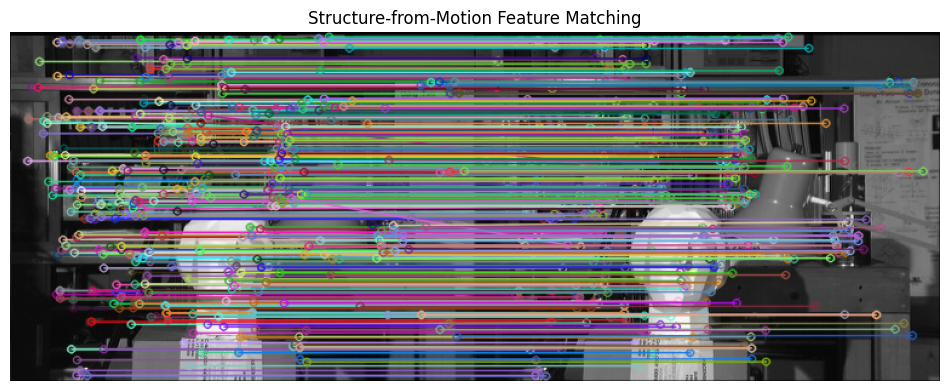

In [18]:
#9. Structure-from-Motion Reconstruction Error Across Varying Image Overlap
img1 = cv2.imread("/content/left.jpg", 0)
img2 = cv2.imread("/content/right.jpg", 0)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

good = []

for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good.append(m)

print("Total Matches:", len(matches))
print("Good Matches:", len(good))

result = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good,
    None,
    flags=2
)

plt.figure(figsize=(12,6))
plt.imshow(result)
plt.title("Structure-from-Motion Feature Matching")
plt.axis("off")
plt.show()

Model 1 F1 Score: 0.758
Model 2 F1 Score: 0.915


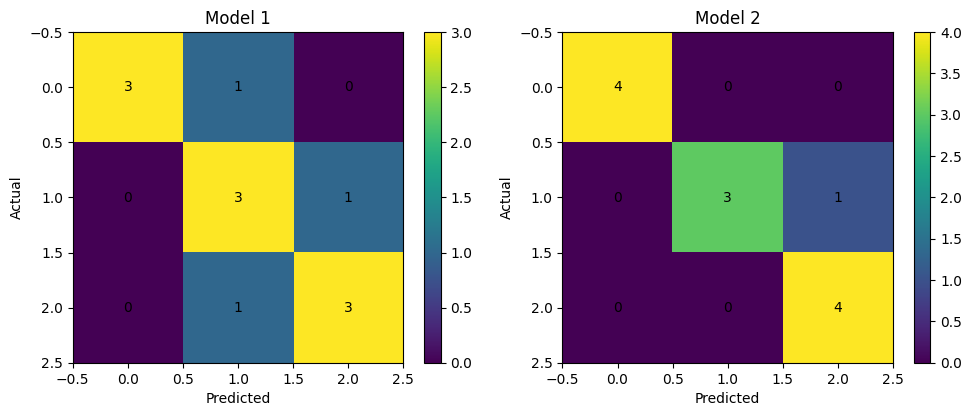

In [19]:
#10. Confusion-Matrix-Based Comparison of Multi-Class Recognition Models
actual = [
    0,0,0,0,
    1,1,1,1,
    2,2,2,2
]

model1 = [
    0,0,1,0,
    1,1,1,2,
    2,2,1,2
]

model2 = [
    0,0,0,0,
    1,1,2,1,
    2,2,2,2
]

cm1 = confusion_matrix(actual, model1)
cm2 = confusion_matrix(actual, model2)

f1_1 = f1_score(actual, model1, average="macro")
f1_2 = f1_score(actual, model2, average="macro")

print("Model 1 F1 Score:", round(f1_1,3))
print("Model 2 F1 Score:", round(f1_2,3))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cm1)
plt.title("Model 1")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(3):
    for j in range(3):
        plt.text(j,i,cm1[i,j],ha="center",va="center")

plt.subplot(1,2,2)
plt.imshow(cm2)
plt.title("Model 2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(3):
    for j in range(3):
        plt.text(j,i,cm2[i,j],ha="center",va="center")

plt.tight_layout()
plt.show()

In [30]:
#11. mAP (mean Average Precision) Computation Across Multiple Object Classes
import os
import numpy as np
import cv2

from ultralytics import YOLO

# Create the dataset directory if it doesn't exist
dataset_dir = "/content/dataset"
os.makedirs(dataset_dir, exist_ok=True)

# Create dummy image and label directories for train and val splits
os.makedirs(os.path.join(dataset_dir, "train", "images"), exist_ok=True)
os.makedirs(os.path.join(dataset_dir, "train", "labels"), exist_ok=True)
os.makedirs(os.path.join(dataset_dir, "val", "images"), exist_ok=True)
os.makedirs(os.path.join(dataset_dir, "val", "labels"), exist_ok=True)

# Create a dummy image and label file for validation
dummy_image = np.ones((640, 640, 3), dtype=np.uint8) * 255  # White image
cv2.imwrite(os.path.join(dataset_dir, "val", "images", "dummy_image.jpg"), dummy_image)
# Create an empty label file for the dummy image
with open(os.path.join(dataset_dir, "val", "labels", "dummy_image.txt"), "w") as f:
    pass # Empty label file as there are no objects

cv2.imwrite(os.path.join(dataset_dir, "train", "images", "dummy_image.jpg"), dummy_image)
# Create an empty label file for the dummy image
with open(os.path.join(dataset_dir, "train", "labels", "dummy_image.txt"), "w") as f:
    pass # Empty label file as there are no objects


# Create a dummy data.yaml file
data_yaml_content = f"""
train: {dataset_dir}/train/images
val: {dataset_dir}/val/images
nc: 1  # number of classes
names: ['object']  # class names
"""

with open(os.path.join(dataset_dir, "data.yaml"), "w") as f:
    f.write(data_yaml_content)

model = YOLO("yolo11n.pt")

result = model.val(
    data=os.path.join(dataset_dir, "data.yaml"),
    verbose=False
)

print("mAP@50:", round(result.box.map50, 3))
print("mAP@50:95:", round(result.box.map, 3))

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 186.5±0.0 MB/s, size: 6.9 KB)
val: Scanning /content/dataset/val/labels... 1 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 843.8it/s 0.0s
val: New cache created: /content/dataset/val/labels.cache
WARNING ⚠️ Labels are missing or empty in /content/dataset/val/labels.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.4it/s 0.3s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:698: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:745: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:745: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all          1          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 2.1ms preprocess, 267.7ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to /content/runs/detect/val-4
mAP@50: 0.0
mAP@50:95: 0.0


,Occlusion (%),Viola-Jones,YOLO
0,0,12,5
1,20,12,5
2,40,8,3
3,60,7,2
4,80,2,1


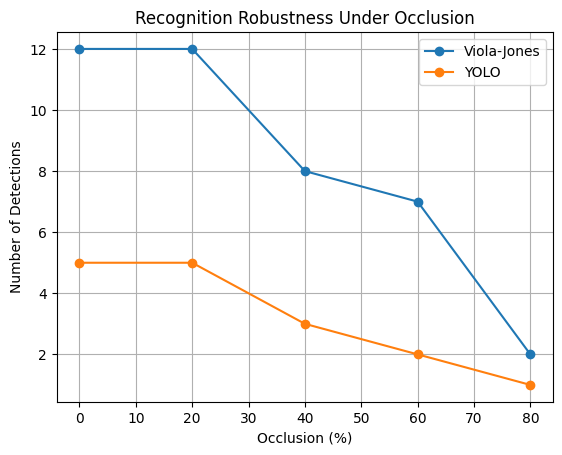

In [31]:
#12. Comparative Robustness Analysis of Recognition Algorithms Under Occlusion
img = cv2.imread("/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png")

face = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

model = YOLO("yolo11n.pt")

levels = [0, 20, 40, 60, 80]
vj_results = []
yolo_results = []

for level in levels:

    test = img.copy()

    h, w = test.shape[:2]

    if level > 0:
        occ_w = int(w * level / 100)
        cv2.rectangle(
            test,
            (0, 0),
            (occ_w, h),
            (0, 0, 0),
            -1
        )

    gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)

    vj = face.detectMultiScale(
        gray,
        1.1,
        5
    )

    yolo = model(
        test,
        conf=0.5,
        verbose=False
    )[0]

    vj_results.append(len(vj))
    yolo_results.append(len(yolo.boxes))

df = pd.DataFrame({
    "Occlusion (%)": levels,
    "Viola-Jones": vj_results,
    "YOLO": yolo_results
})

display(df)

plt.plot(
    levels,
    vj_results,
    marker="o",
    label="Viola-Jones"
)

plt.plot(
    levels,
    yolo_results,
    marker="o",
    label="YOLO"
)

plt.xlabel("Occlusion (%)")
plt.ylabel("Number of Detections")
plt.title("Recognition Robustness Under Occlusion")
plt.legend()
plt.grid()
plt.show()